In [1]:
# PCA sweep: accuracy vs number of components
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut, train_test_split
from sklearn.metrics import make_scorer, confusion_matrix, balanced_accuracy_score

In [2]:
# Load paired metadata and masked parquet data
paired_df = pd.read_csv("model_data/adni/paired_df_full.csv", index_col=0)

dti_masked_wm = pd.read_parquet("model_data/adni/dti_masked_wm.parquet")
dti_masked_gm = pd.read_parquet("model_data/adni/dti_masked_gm.parquet")
t1_masked_wm = pd.read_parquet("model_data/adni/t1_masked_wm.parquet")
t1_masked_gm = pd.read_parquet("model_data/adni/t1_masked_gm.parquet")

# Build lookup dicts (file_name -> masked_data)
dti_wm_lookup = dti_masked_wm.set_index("file_name")["masked_data"].to_dict()
dti_gm_lookup = dti_masked_gm.set_index("file_name")["masked_data"].to_dict()
t1_wm_lookup = t1_masked_wm.set_index("file_name")["masked_data"].to_dict()
t1_gm_lookup = t1_masked_gm.set_index("file_name")["masked_data"].to_dict()

# Build matrices aligned to paired_df row order (ensures DTI and T1 rows match)
dti_wm_arrays = [dti_wm_lookup[fn] for fn in paired_df["dti_file_name"]]
dti_gm_arrays = [dti_gm_lookup[fn] for fn in paired_df["dti_file_name"]]
t1_wm_arrays = [t1_wm_lookup[fn] for fn in paired_df["t1_file_name"]]
t1_gm_arrays = [t1_gm_lookup[fn] for fn in paired_df["t1_file_name"]]

dti_wm_matrix = np.array(dti_wm_arrays)
dti_gm_matrix = np.array(dti_gm_arrays)
t1_wm_matrix = np.array(t1_wm_arrays)
t1_gm_matrix = np.array(t1_gm_arrays)

In [3]:
def balanced_accuracy_scorer(y_true, y_pred):
    """Balanced accuracy with explicit labels to avoid sklearn warnings in edge cases (e.g., single-class test fold)."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    recalls = []
    for i in range(2):
        n = cm[i, :].sum()
        recalls.append(cm[i, i] / n if n > 0 else 0.0)
    return np.mean(recalls)

In [4]:
balanced_accuracy_scorer_obj = make_scorer(balanced_accuracy_scorer)

In [5]:
# Standardize each dataset
scaler_dti_wm = StandardScaler()
scaler_dti_gm = StandardScaler()
scaler_t1_wm = StandardScaler()
scaler_t1_gm = StandardScaler()

dti_wm_scaled = scaler_dti_wm.fit_transform(dti_wm_matrix)
dti_gm_scaled = scaler_dti_gm.fit_transform(dti_gm_matrix)
t1_wm_scaled = scaler_t1_wm.fit_transform(t1_wm_matrix)
t1_gm_scaled = scaler_t1_gm.fit_transform(t1_gm_matrix)

In [6]:
# Labels and groups for cross-validation
trial_labels = np.array(paired_df["label"])  # class labels 0/1
run_labels = np.array(paired_df["subject_id"])  # for grouped CV (avoid subject leakage)

In [7]:
# Fit PCA with max components once (efficient: slice for each n without refitting)
pca_dti_wm_full = PCA(n_components=150).fit(dti_wm_scaled)
pca_dti_gm_full = PCA(n_components=150).fit(dti_gm_scaled)
pca_t1_wm_full = PCA(n_components=150).fit(t1_wm_scaled)
pca_t1_gm_full = PCA(n_components=150).fit(t1_gm_scaled)

In [8]:
# Comparison: model_v1-style evaluation (train_test_split + RBF, no subject grouping)
# Should reproduce ~0.77. Lower accuracy with LeaveOneGroupOut is expected:
# train_test_split can put same subject in train & test (subject leakage); LeaveOneGroupOut leaves
# entire subjects out, giving a realistic estimate of performance on new subjects.
n_compare = 100  # model_v1 uses 100 PCA components per modality
data_compare = np.hstack([
    pca_dti_wm_full.transform(dti_wm_scaled)[:, :n_compare],
    pca_dti_gm_full.transform(dti_gm_scaled)[:, :n_compare],
    pca_t1_wm_full.transform(t1_wm_scaled)[:, :n_compare],
    pca_t1_gm_full.transform(t1_gm_scaled)[:, :n_compare],
])
X_train, X_test, y_train, y_test = train_test_split(
    data_compare, trial_labels, test_size=0.2, random_state=42, stratify=trial_labels
)
svm_compare = SVC(kernel="rbf", random_state=42)  # matches model_v1
svm_compare.fit(X_train, y_train)
y_pred_compare = svm_compare.predict(X_test)
print(f"model_v1-style (train_test_split, RBF, n=100): balanced accuracy = {balanced_accuracy_score(y_test, y_pred_compare):.4f}")

model_v1-style (train_test_split, RBF, n=100): balanced accuracy = 0.6480


In [9]:
# Test single iteration before full sweep (n=50)
n_test = 50
cv = LeaveOneGroupOut()

dti_wm_n = pca_dti_wm_full.transform(dti_wm_scaled)[:, :n_test]
dti_gm_n = pca_dti_gm_full.transform(dti_gm_scaled)[:, :n_test]
t1_wm_n = pca_t1_wm_full.transform(t1_wm_scaled)[:, :n_test]
t1_gm_n = pca_t1_gm_full.transform(t1_gm_scaled)[:, :n_test]
data_test = np.hstack([dti_wm_n, dti_gm_n, t1_wm_n, t1_gm_n])

classifier = SVC(kernel="rbf", class_weight="balanced", random_state=42)
scores_test = cross_val_score(
    classifier,
    data_test,
    trial_labels,
    cv=cv,
    groups=run_labels,
    scoring=balanced_accuracy_scorer_obj,
)
print(f"Test (n={n_test}): mean balanced accuracy = {scores_test.mean():.4f} (+/- {scores_test.std() * 2:.4f})")

Test (n=50): mean balanced accuracy = 0.2926 (+/- 0.4613)


In [25]:
# PCA sweep: vary n_components every 10 from 10 to 150
n_components_range = range(10, 151, 10)
accuracies = []
cv = LeaveOneGroupOut()

for n in tqdm(n_components_range, desc="PCA sweep"):
    dti_wm_n = pca_dti_wm_full.transform(dti_wm_scaled)[:, :n]
    dti_gm_n = pca_dti_gm_full.transform(dti_gm_scaled)[:, :n]
    t1_wm_n = pca_t1_wm_full.transform(t1_wm_scaled)[:, :n]
    t1_gm_n = pca_t1_gm_full.transform(t1_gm_scaled)[:, :n]
    data = np.hstack([dti_wm_n, dti_gm_n, t1_wm_n, t1_gm_n])

    classifier = SVC(kernel="rbf", class_weight="balanced", random_state=42)
    scores = cross_val_score(
        classifier,
        data,
        trial_labels,
        cv=cv,
        groups=run_labels,
        scoring=balanced_accuracy_scorer_obj,
    )
    accuracies.append(scores.mean())

PCA sweep: 100%|██████████| 15/15 [02:21<00:00,  9.45s/it]


PCA sweep: 100%|██████████| 15/15 [24:38<00:00, 98.57s/it] 


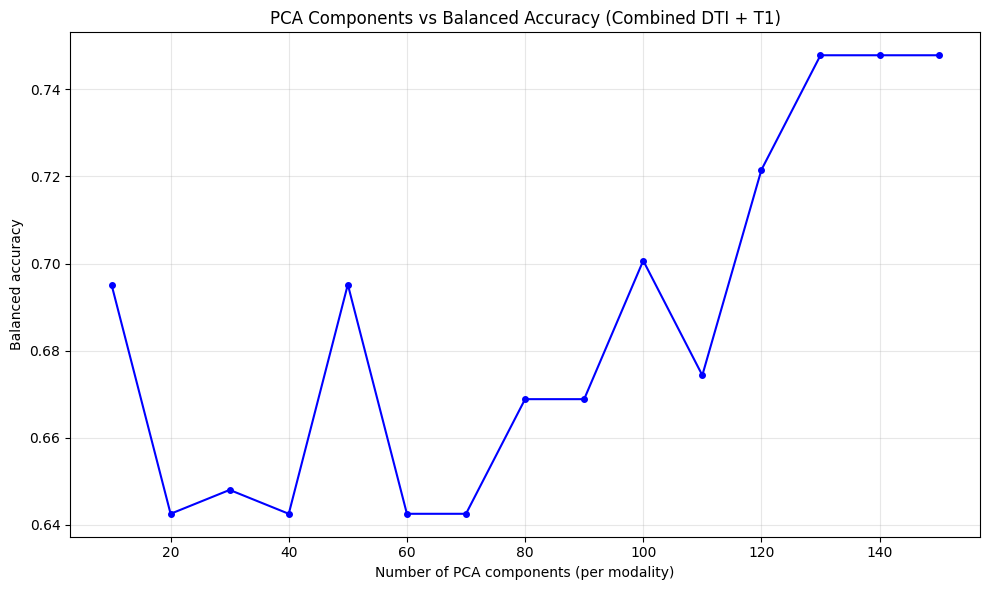

In [14]:
# Fixed train/test split on raw indices, PCA fit on ALL data (model_v1 style)
indices = np.arange(len(trial_labels))
idx_train, idx_test, y_train, y_test = train_test_split(
    indices, trial_labels, test_size=0.2, random_state=42, stratify=trial_labels
)

n_components_range = range(10, 151, 10)
accuracies = []

for n in tqdm(n_components_range, desc="PCA sweep"):
    pca_models = [PCA(n_components=n) for _ in range(4)]
    scaled_datasets = [dti_wm_scaled, dti_gm_scaled, t1_wm_scaled, t1_gm_scaled]

    train_parts = []
    test_parts = []
    for pca_model, scaled_data in zip(pca_models, scaled_datasets):
        pca_model.fit(scaled_data)
        train_parts.append(pca_model.transform(scaled_data[idx_train]))
        test_parts.append(pca_model.transform(scaled_data[idx_test]))

    X_train = np.hstack(train_parts)
    X_test = np.hstack(test_parts)

    classifier = SVC(kernel="rbf", random_state=42)
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    accuracies.append(balanced_accuracy_score(y_test, y_pred))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(n_components_range), accuracies, "b-o", markersize=4)
ax.set_xlabel("Number of PCA components (per modality)")
ax.set_ylabel("Balanced accuracy")
ax.set_title("PCA Components vs Balanced Accuracy (Combined DTI + T1)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()